In [19]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
import pyresample as pr
from pyresample import kd_tree, parse_area_file
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from pyresample.geometry import SwathDefinition
import sys, string, math, cmath
from numba import jit 
from tqdm import tqdm 
import time 
from pyresample.geometry import SwathDefinition
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import FixedLocator 
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import maximum_filter, minimum_filter

In [20]:
# Open the filtered swath data and store it in a Pandas Dataframe
file_path_swath ='data_swath4.txt'
data_swath = pd.read_csv(file_path_swath, delimiter='\t')

# Convert all numeric columns to numeric data types
numeric_columns = ['TBCH1', 'TBCH2', 'TBCH3', 'LAT', 'LON', 'u10', 
                   'v10', 't2m', 'tcw', 'tcwv', 'sst', 'siconc',
                   'theta', 'clw', 'W', 'siconc_unc_ch1', 
                   'siconc_unc_ch2', 'T22_measured', 'T32_measured',
                   'T22_mean', 'T32_mean', 'TBCH1_corr', 'TBCH2_corr',
                   'siconc_ch1_corr', 'siconc_ch2_corr']

data_swath[numeric_columns] = data_swath[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Convert 'datetime' column to datetime type 
data_swath['datetime'] = pd.to_datetime(data_swath['datetime'])

# Define conditions for filtering based on regions of interest
myi_condition = (data_swath['LAT'] > 80) & (data_swath['LAT'] < 90) & (data_swath['LON'] > -180) & (data_swath['LON'] < 0)
fyi_condition_arctic = (data_swath['LAT'] > 70) & (data_swath['LAT'] < 80) & (data_swath['LON'] > 0) & (data_swath['LON'] < 180)
fyi_condition_antarctic = (data_swath['LAT'] < -70) & (data_swath['LAT'] > -80) & (data_swath['LON'] > -180) & (data_swath['LON'] < 180)

# Define two conditions for each ice-type using logical OR
fyi_condition = (
    (fyi_condition_arctic) |  # First-Year Ice condition in the Arctic
    (fyi_condition_antarctic)  # First-Year Ice condition in the Antarctic
)

myi_condition = (myi_condition)  # Multi-Year Ice condition (Only Arctic)

# Filter the data based on the regions of interest 
data_swath_fyi = data_swath[fyi_condition].dropna() # FYI
data_swath_myi = data_swath[myi_condition].dropna() # MYI

In [21]:
#UNCORRECTED TIE POINTS

# Divide the data based on the 'LAT' column and open water/ice type
data_nh_ow = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh_ow = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0

data_nh_fyi = data_swath_fyi[data_swath_fyi['LAT'] > 0] 
data_sh_fyi = data_swath_fyi[data_swath_fyi['LAT'] < 0]

data_nh_myi = data_swath_myi[data_swath_myi['LAT'] > 0] 
data_sh_myi = data_swath_myi[data_swath_myi['LAT'] < 0]

# Function to calculate open water, FYI and MYI tie points
def two_channel_tie_points_calculator(tb_data_fyi, tb_data_myi, tb_data_ow, sic_data_fyi, 
                                      sic_data_myi, sic_data_ow, ice_threshold=0.99, open_water_threshold=0.01):
    """
    Derive tie points for first-year ice (FYI), multi-year ice (MYI) and open water (OW) 
    from brightness temperature and SIC data for the two channel algorithm.
    
    Parameters:
    
    tb_data_ow (array): Brightness temperature values (K) for all regions of open water.
    tb_data_fyi (array): Brightness temperature values (K) for regions of first-year ice.
    tb_data_myi (array): Brightness temperature values (K) for regions of multi-year ice.
    
    sic_data_ow (array): ERA5-model SIC values (0 to 1) for all regions of open water.
    sic_data_fyi (array): ERA5-model SIC values (0 to 1) for regions of first-year ice.
    sic_data_myi (array): ERA5-model SIC values (0 to 1) for regions of multi-year ice.
    
    ice_threshold (float): Threshold to classify ice at SIC > 0.99 (Likely to find ice).
    open_water_threshold (float): Threshold to classify open water at SIC < 0.01 (no ice).
    
    Returns:
    tuple: (Tie point for open water, Tie point for ice)
    """
    # Filter data for SIC ≈ 0 (open water) and SIC ≈ 1 (ice)
    open_water_tb = tb_data_ow[sic_data_ow <= open_water_threshold]
    ice_fyi_tb = tb_data_fyi[sic_data_fyi >= ice_threshold]
    ice_myi_tb = tb_data_myi[sic_data_myi >= ice_threshold]
    
    # Calculate mean brightness temperatures as tie points
    tp_open_water = np.mean(open_water_tb) if len(open_water_tb) > 0 else np.nan
    tp_fyi_ice = np.mean(ice_fyi_tb) if len(ice_fyi_tb) > 0 else np.nan
    tp_myi_ice = np.mean(ice_myi_tb) if len(ice_myi_tb) > 0 else np.nan
    
    return tp_open_water, tp_fyi_ice, tp_myi_ice

In [22]:
# NORTHEN HEMISPHERE

# TBCH1 for all types of regions
tb1_data_fyi_nh = data_nh_fyi['TBCH1']
tb1_data_myi_nh = data_nh_myi['TBCH1']
tb1_data_ow_nh = data_nh_ow['TBCH1']

# TBCH2 for all types of regions
tb2_data_fyi_nh = data_nh_fyi['TBCH2']
tb2_data_myi_nh = data_nh_myi['TBCH2']
tb2_data_ow_nh = data_nh_ow['TBCH2']

# ERA-5 SIC for all types of regions
sic_data_fyi_nh =  data_nh_fyi['siconc']
sic_data_myi_nh = data_nh_myi['siconc']
sic_data_ow_nh = data_nh_ow['siconc']

# Group by datetime
grouped_fyi = data_nh_fyi.groupby('datetime')
grouped_myi = data_nh_myi.groupby('datetime')
grouped_ow  = data_nh_ow.groupby('datetime')

# Find common dates
common_dates = set(grouped_fyi.groups) & set(grouped_myi.groups) & set(grouped_ow.groups)

# Prepare list to collect results
daily_results = []

for date in sorted(common_dates):
    # Extract daily data for each region
    group_fyi = grouped_fyi.get_group(date)
    group_myi = grouped_myi.get_group(date)
    group_ow  = grouped_ow.get_group(date)

    # TBCH1 for all types of regions
    tb1_data_fyi_nh = group_fyi['TBCH1']
    tb1_data_myi_nh = group_myi['TBCH1']
    tb1_data_ow_nh  = group_ow['TBCH1']

    # TBCH2 for all types of regions
    tb2_data_fyi_nh = group_fyi['TBCH2']
    tb2_data_myi_nh = group_myi['TBCH2']
    tb2_data_ow_nh  = group_ow['TBCH2']

    # ERA-5 SIC for all types of regions
    sic_data_fyi_nh = group_fyi['siconc']
    sic_data_myi_nh = group_myi['siconc']
    sic_data_ow_nh  = group_ow['siconc']

    # Derive tie points for Channel 1 (22 GHz)
    tp_open_water_22ghz_nh, tp_fyi_ice_22ghz_nh, tp_myi_ice_22ghz_nh = two_channel_tie_points_calculator(
        tb1_data_fyi_nh, tb1_data_myi_nh, tb1_data_ow_nh,
        sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Derive tie points for Channel 2 (32 GHz)
    tp_open_water_32ghz_nh, tp_fyi_ice_32ghz_nh, tp_myi_ice_32ghz_nh = two_channel_tie_points_calculator(
        tb2_data_fyi_nh, tb2_data_myi_nh, tb2_data_ow_nh,
        sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Save results in dictionary format for DataFrame
    daily_results.append({
        'datetime': date,
        'tp_open_water_22ghz_nh': tp_open_water_22ghz_nh,
        'tp_fyi_ice_22ghz_nh': tp_fyi_ice_22ghz_nh,
        'tp_myi_ice_22ghz_nh': tp_myi_ice_22ghz_nh,
        'tp_open_water_32ghz_nh': tp_open_water_32ghz_nh,
        'tp_fyi_ice_32ghz_nh': tp_fyi_ice_32ghz_nh,
        'tp_myi_ice_32ghz_nh': tp_myi_ice_32ghz_nh
    })

# Convert results to DataFrame
daily_tie_points_nh = pd.DataFrame(daily_results)

# Save to file (optional)
daily_tie_points_nh.to_csv("daily_tie_points_nh.txt", index=False)

# Print results
print("Daily Tie Points for Northern Hemisphere:")
print(daily_tie_points_nh)

Daily Tie Points for Northern Hemisphere:
     datetime  tp_open_water_22ghz_nh  tp_fyi_ice_22ghz_nh  \
0  1976-03-01              171.476156           239.151631   
1  1976-03-02              171.039789           239.708622   
2  1976-03-03              171.131200           237.232170   
3  1976-03-04              171.027774           242.388298   
4  1976-03-05              171.083822           236.356148   
5  1976-03-06              170.642170           238.350914   
6  1976-03-07              171.414151           237.999436   
7  1976-03-08              169.847644           237.909943   
8  1976-03-09              169.952829           237.963319   
9  1976-03-10              172.520450           238.892083   
10 1976-03-11              172.388428           237.495943   
11 1976-03-12              171.209591           235.524623   
12 1976-03-13              170.625321           235.534022   
13 1976-03-14              172.690007           235.705304   
14 1976-03-15              1

In [30]:
# SOUTHERN HEMISPHERE

# TBCH1 for all types of regions
tb1_data_fyi_sh = data_sh_fyi['TBCH1']
tb1_data_myi_sh = data_nh_myi['TBCH1'] # We use the north hemisphere MYI signature for Antarctica as well
tb1_data_ow_sh = data_sh_ow['TBCH1']

# TBCH2 for all types of regions
tb2_data_fyi_sh = data_sh_fyi['TBCH2']
tb2_data_myi_sh = data_nh_myi['TBCH2'] # We use the north hemisphere MYI signature for Antarctica as well
tb2_data_ow_sh = data_sh_ow['TBCH2']

# ERA-5 SIC for all types of regions
sic_data_fyi_sh =  data_sh_fyi['siconc']
sic_data_myi_sh = data_nh_myi['siconc'] # We use the north hemisphere MYI signature for Antarctica as well
sic_data_ow_sh = data_sh_ow['siconc']


# Group by datetime
grouped_fyi = data_sh_fyi.groupby('datetime')
grouped_myi = data_nh_myi.groupby('datetime')
grouped_ow  = data_sh_ow.groupby('datetime')

# Find common dates
common_dates = set(grouped_fyi.groups) & set(grouped_myi.groups) & set(grouped_ow.groups)

# Prepare list to collect results
daily_results = []

for date in sorted(common_dates):
    # Extract daily data for each region
    group_fyi = grouped_fyi.get_group(date)
    group_myi = grouped_myi.get_group(date)
    group_ow  = grouped_ow.get_group(date)

    # TBCH1 for all types of regions
    tb1_data_fyi_sh = group_fyi['TBCH1']
    tb1_data_myi_nh = group_myi['TBCH1']
    tb1_data_ow_sh  = group_ow['TBCH1']

    # TBCH2 for all types of regions
    tb2_data_fyi_sh = group_fyi['TBCH2']
    tb2_data_myi_nh = group_myi['TBCH2']
    tb2_data_ow_sh  = group_ow['TBCH2']

    # ERA-5 SIC for all types of regions
    sic_data_fyi_sh = group_fyi['siconc']
    sic_data_myi_nh = group_myi['siconc']
    sic_data_ow_sh  = group_ow['siconc']

    # Derive tie points for Channel 1 (22 GHz)
    tp_open_water_22ghz_sh, tp_fyi_ice_22ghz_sh, tp_myi_ice_22ghz_sh = two_channel_tie_points_calculator(
        tb1_data_fyi_sh, tb1_data_myi_nh, tb1_data_ow_sh,
        sic_data_fyi_sh, sic_data_myi_nh, sic_data_ow_sh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Derive tie points for Channel 2 (32 GHz)
    tp_open_water_32ghz_sh, tp_fyi_ice_32ghz_sh, tp_myi_ice_32ghz_sh = two_channel_tie_points_calculator(
        tb2_data_fyi_sh, tb2_data_myi_nh, tb2_data_ow_sh,
        sic_data_fyi_sh, sic_data_myi_nh, sic_data_ow_sh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Save results in dictionary format for DataFrame
    daily_results.append({
        'datetime': date,
        'tp_open_water_22ghz_sh': tp_open_water_22ghz_sh,
        'tp_fyi_ice_22ghz_sh': tp_fyi_ice_22ghz_sh,
        'tp_myi_ice_22ghz_sh': tp_myi_ice_22ghz_sh,
        'tp_open_water_32ghz_sh': tp_open_water_32ghz_sh,
        'tp_fyi_ice_32ghz_sh': tp_fyi_ice_32ghz_sh,
        'tp_myi_ice_32ghz_sh': tp_myi_ice_32ghz_sh
    })

# Convert results to DataFrame
daily_tie_points_sh = pd.DataFrame(daily_results)

# Save to file (optional)
daily_tie_points_sh.to_csv("daily_tie_points_sh.txt", index=False)

# Print results
print("Daily Tie Points for Southern Hemisphere:")
print(daily_tie_points_sh)


Daily Tie Points for Southern Hemisphere:
     datetime  tp_open_water_22ghz_sh  tp_fyi_ice_22ghz_sh  \
0  1976-03-01              161.412356           232.343733   
1  1976-03-02              162.441532           226.184531   
2  1976-03-03              161.789059           233.553500   
3  1976-03-04              160.458567           218.158121   
4  1976-03-05              159.690505           226.779913   
5  1976-03-06              159.200733           225.466943   
6  1976-03-07              159.268676           221.852587   
7  1976-03-08              159.951441           222.284625   
8  1976-03-09              161.281238           225.802353   
9  1976-03-10              160.080555           229.682646   
10 1976-03-11              160.409061           231.733683   
11 1976-03-12              160.598296           228.796451   
12 1976-03-13              159.729347           235.158095   
13 1976-03-14              157.768870           234.209847   
14 1976-03-15              1

In [129]:
def fcomiso(tb_22_GHz, tb_32_GHz, tie_points):
    """
    Comiso 2-channel sea ice concentration algorithm.
    
    Parameters:
        tb_22_GHz (float): Brightness temperature at 22 GHz.
        tb_32_GHz (float): Brightness temperature at 32 GHz.
        tie_points (list or tuple): Tie points in the following order:
            [tp_ow_22v, tp_ow_32v, tp_myi_22v, tp_myi_32v, tp_fyi_22v, tp_fyi_32v]
    
    Returns:
        float: Estimated sea ice concentration.
    """
    try:
        tp_ow_22v, tp_ow_32v, tp_myi_22v, tp_myi_32v, tp_fyi_22v, tp_fyi_32v = tie_points

        # Calculate ice concentration using Comiso formulation
        af = (tp_fyi_32v - tp_myi_32v) / (tp_fyi_22v - tp_myi_22v)
        bf = tp_myi_32v - af * tp_myi_22v
        qf = (tb_32_GHz - tp_ow_32v) / (tb_22_GHz - tp_ow_22v)
        wf = tp_ow_32v - qf * tp_ow_22v
        ti22vf = (bf - wf) / (qf - af)
        sic_2_channels = (tb_22_GHz - tp_ow_22v) / (ti22vf - tp_ow_22v)

        return sic_2_channels

    except Exception as e:
        print(f"Error computing fcomiso SIC: {e}")
        return np.nan

In [131]:
# Function to implement the two channels algorithm for SIC computation at both hemispheres on swath-type dataframe
def calculate_SIC_two_channels(swath_data, TB1_col, TB2_col, 
                               daily_tie_points_nh, daily_tie_points_sh,
                               output_col_sic='siconc_unc_2_channels'):
    """
    Calculate SIC using dynamic daily tie points from both hemispheres.

    Parameters:
        swath_data (pd.DataFrame): Swath-type input DataFrame with 'datetime' and 'LAT'.
        TB1_col (str): Column name for 22 GHz TB.
        TB2_col (str): Column name for 32 GHz TB.
        daily_tie_points_nh (pd.DataFrame): Daily tie points for Northern Hemisphere.
        daily_tie_points_sh (pd.DataFrame): Daily tie points for Southern Hemisphere.
        output_col_sic (str): Output column name for SIC.

    Returns:
        pd.DataFrame: Input DataFrame with added SIC column.
    """

    # Merge tie points into swath data by hemisphere and datetime
    swath_data_nh = swath_data[swath_data['LAT'] > 0].merge(
        daily_tie_points_nh, on='datetime', how='left')
    swath_data_sh = swath_data[swath_data['LAT'] < 0].merge(
        daily_tie_points_sh, on='datetime', how='left')

    swath_data_merged = pd.concat([swath_data_nh, swath_data_sh], ignore_index=True)

    # Define SIC computation per row
    def compute_sic(row):
        tie_points = [
            row['tp_open_water_22ghz_nh'] if row['LAT'] > 0 else row['tp_open_water_22ghz_sh'],
            row['tp_open_water_32ghz_nh'] if row['LAT'] > 0 else row['tp_open_water_32ghz_sh'],
            row['tp_myi_ice_22ghz_nh']     if row['LAT'] > 0 else row['tp_myi_ice_22ghz_sh'],
            row['tp_myi_ice_32ghz_nh']     if row['LAT'] > 0 else row['tp_myi_ice_32ghz_sh'],
            row['tp_fyi_ice_22ghz_nh']     if row['LAT'] > 0 else row['tp_fyi_ice_22ghz_sh'],
            row['tp_fyi_ice_32ghz_nh']     if row['LAT'] > 0 else row['tp_fyi_ice_32ghz_sh'],
        ]
        return fcomiso(row[TB1_col], row[TB2_col], tie_points=tie_points)

    # Apply and postprocess
    swath_data_merged[output_col_sic] = swath_data_merged.apply(compute_sic, axis=1)
    swath_data_merged[output_col_sic] = swath_data_merged[output_col_sic].clip(lower=0, upper=1)
    swath_data_merged.loc[swath_data_merged[output_col_sic] < 0.15, output_col_sic] = 0

    return swath_data

# Call the function and calculate the sea ice concentration using the two-channel algorithm
data_swath = calculate_SIC_two_channels(
    swath_data=data_swath,                     # Selected swath-type DataFrame
    TB1_col='TBCH1',                           # 22 GHz brightness temperature
    TB2_col='TBCH2',                           # 32 GHz brightness temperature
    daily_tie_points_nh=daily_tie_points_nh,   # Daily NH tie points
    daily_tie_points_sh=daily_tie_points_sh,   # Daily SH tie points
    output_col_sic='siconc_unc_2_channels'     # New SIC column
)

In [132]:
# Define the function to compute the tie-points-based means for the atmospheric variables for each hemisphere
def calculate_tie_point_means_for_hemispheres(data_nh, data_sh, ice_threshold=0.99, open_water_threshold=0.01):

    """
    Calculate tie-point-based means for open water and ice for specific variables
    for both hemispheres and return all means as a dictionary.
    
    Parameters:
    data_nh (pd.DataFrame): DataFrame for the Northern Hemisphere.
    data_sh (pd.DataFrame): DataFrame for the Southern Hemisphere.
    ice_threshold (float): SIC threshold to classify ice (default: > 0.99).
    open_water_threshold (float): SIC threshold to classify open water (default: < 0.01).
    
    Returns:
    dict: A dictionary with variable names for both hemispheres and their open water and ice means.
    """
    def calculate_means(data, hemisphere):
        # Separate the data into open water and ice based on 'siconc_r'
        open_water_mask = data['siconc'] < open_water_threshold
        ice_mask = data['siconc'] > ice_threshold

        # Calculate means for each variable explicitly with unique names
        return {
            f't2m_mean_open_water_{hemisphere}': data.loc[open_water_mask, 't2m'].mean(),
            f't2m_mean_ice_{hemisphere}': data.loc[ice_mask, 't2m'].mean(),
            
            f'sst_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'sst'].mean(),
            f'sst_mean_ice_{hemisphere}': data.loc[ice_mask, 'sst'].mean(),
            
            f'tcwv_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'tcwv'].mean(),
            f'tcwv_mean_ice_{hemisphere}': data.loc[ice_mask, 'tcwv'].mean(),
            
            f'clw_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'clw'].mean(),
            f'clw_mean_ice_{hemisphere}': data.loc[ice_mask, 'clw'].mean(),
            
            f'W_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'W'].mean(),
            f'W_mean_ice_{hemisphere}': data.loc[ice_mask, 'W'].mean(),
        }

    # Calculate means for both hemispheres
    means_nh = calculate_means(data_nh, 'NH')
    means_sh = calculate_means(data_sh, 'SH')

    # Combine results into a single dictionary
    return {**means_nh, **means_sh}


# Import the two hemispheric datasets for tie-points-based means
file_path_nh = 'swath_based_filtered_data_nh.txt'
file_path_sh = 'swath_based_filtered_data_sh.txt'
data_nh = pd.read_csv(file_path_nh, delimiter='\t')
data_sh = pd.read_csv(file_path_sh, delimiter='\t')

# Calculate tie-points-based means for both hemispheres
tie_point_means = calculate_tie_point_means_for_hemispheres(data_nh, data_sh)

In [133]:
# Divide the data based on the 'LAT' column
data_nh = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0


# Calculate tie-points-based means for the atmospheric variables in both hemispheres
tie_point_means = calculate_tie_point_means_for_hemispheres(data_nh, data_sh)

In [134]:
# Define Optimized RTM Function

@jit(nopython=True)  # This compiles the function into machine code
def scams_optimized(V, W, L, Ta, Ts, theta, Ti_amsrv, Ti_amsrh, c_ice_ch1, c_ice_ch2, e_icev, e_iceh):
    
    """---------------------------------------------------------------------------
     AMSR Ocean Algorithm; Frank J. Wentz, Thomas Meissner; Remote
     Sensing Systems; Version 2; November 2; 2000. Modified to NIMBUS 6 SCAMS geometry.
     NIMBUS 6 SCAMS Scanning Microwave Spectrometer 145 km spatial resolution 2400 km swath
     T22, T32: scams(V,W,L,Ta,Ts,theta,Ti_amsrv,Ti_amsrh,c_ice_ch1, c_ice_ch2,e_icev,e_iceh)
     V: columnar water vapor [mm] # we use the mean value from the tie points 
     W: windspeed over water [m/s] # we use the mean value from the tie points
     L: columnar cloud liquid water [mm] # we use the mean value from the tie points that is L=tcw-tcwv in our ERA5 model variables
     Ti_amrsv: ice emitting layer temperature (usually warmer than atmosphere temperature in Winter) vertical polarization
     Ti_amrsh: ice emitting layer temperature (usually warmer than atmosphere temperature in Winter) horizontal polarization
     Ti: 0.6*Ta + 0.4 # we use this fixed value in the equation
     Ta: atmospheric temperature at 2 m altitude = t2m in our ERA5-data 
     Ts: sea surface temperature [K]
     theta: incidence angle [deg]
     Ti: ice surface temperature [K]
     c_ice: ice concentration [0-1]
     e_ice: ice emissivity [0-1]  We use the same ice emissivity: 0.8 for horizontal polarization and 0.9 for vertical polarization (educated guess)
     -------------------------------------------------------------------------------"""
    frequencies = np.array([23.80, 36.50])

    b0 = np.array([241.69, 239.45])
    b1 = np.array([310.32E-2, 254.41E-2])
    b2 = np.array([-814.29E-4, -512.84E-4])
    b3 = np.array([998.93E-6, 452.02E-6])
    b4 = np.array([-48.37E-7, -14.36E-7])
    b5 = np.array([0.20, 0.58])
    b6 = np.array([-0.20, -0.57])
    b7 = np.array([-5.21E-2, -2.38E-2])
    ao1 = np.array([15.75E-3, 40.06E-3])
    ao2 = np.array([-0.87E-4, -2.00E-4])
    av1 = np.array([5.14E-3, 1.88E-3])
    av2 = np.array([0.19E-5, 0.09E-5])

    aL1 = np.array([0.0891, 0.2027])
    aL2 = np.array([0.0281, 0.0261])

    r0v = np.array([-0.63E-3, -1.01E-3])
    r0h = np.array([1.39E-3, 1.91E-3])
    r1v = np.array([-0.70E-4, -1.05E-4])
    r1h = np.array([0.85E-4, 1.12E-4])
    r2v = np.array([-2.10E-5, -2.10E-5])
    r2h = np.array([-41.95E-6, -54.51E-6])
    r3v = np.array([0.41E-6, 0.45E-6])
    r3h = np.array([-0.20E-6, -0.36E-6])

    m1v = np.array([0.00178, 0.00257])
    m1h = np.array([0.00308, 0.00329])
    m2v = np.array([0.00730, 0.00701])
    m2h = np.array([0.00660, 0.00660])

    # Constants
    T_C = 2.7
    light_speed = 3.00E10
    epsilon_R = 4.44
    s = 35.0
    ny = 0.012

    
    # Precompute mixed temperatures for both channels
    Ts_mix_ch1 = c_ice_ch1 * Ta + (1.0 - c_ice_ch1) * Ts
    Ts_mix_ch2 = c_ice_ch2 * Ta + (1.0 - c_ice_ch2) * Ts

    Tl_ch1 = (Ts_mix_ch1 + 273.0) / 2.0
    Tl_ch2 = (Ts_mix_ch2 + 273.0) / 2.0

    # Eq. 27
    Tv = np.where(V > 48, 301.16, 273.16 + 0.8337 * V - 3.029E-5 * (V**3.33))

    # Precompute G for both channels
    Ts_Tv_diff_ch1 = Ts_mix_ch1 - Tv
    Ts_Tv_diff_ch2 = Ts_mix_ch2 - Tv

    G_ch1 = np.where(
        np.abs(Ts_Tv_diff_ch1) > 20,
        Ts_Tv_diff_ch1 * 14 / np.abs(Ts_Tv_diff_ch1),
        1.05 * Ts_Tv_diff_ch1 * (1 - (Ts_Tv_diff_ch1**2) / 1200.0)
    )
    G_ch2 = np.where(
        np.abs(Ts_Tv_diff_ch2) > 20,
        Ts_Tv_diff_ch2 * 14 / np.abs(Ts_Tv_diff_ch2),
        1.05 * Ts_Tv_diff_ch2 * (1 - (Ts_Tv_diff_ch2**2) / 1200.0)
    )

    # Shared precomputations
    Ts_K = Ts - 273.15
    epsilon_S = 87.90 * np.exp(-0.004585 * Ts_K) * np.exp(-3.45E-3 * s + 4.69E-6 * s**2 + 1.36E-5 * s * Ts_K)
    lambda_R = 3.30 * np.exp(-0.0346 * Ts_K + 0.00017 * Ts_K**2) - (6.54E-3 * (1 - 3.06E-2 * Ts_K + 2.0E-4 * Ts_K**2) * s)
    C = 0.5536 * s
    delta_t = 25.0 - Ts_K
    qsi = (
        2.03E-2
        + 1.27E-4 * delta_t
        + 2.46E-6 * delta_t**2
        - C * (3.34E-5 - 4.60E-7 * delta_t + 4.60E-8 * delta_t**2)
    )
    sigma = 3.39E9 * (C**0.892) * np.exp(-delta_t * qsi)

    # Initialize output arrays
    tau = np.zeros(2)
    TBU = np.zeros(2)
    TBD = np.zeros(2)
    emissivity_h = np.zeros(2)
    emissivity_v = np.zeros(2)
    T_BOmegaH = np.zeros(2)
    T_BOmegaV = np.zeros(2)

    theta_rad = np.radians(theta)
    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)

    # Vectorized loop computations
    for i in range(2):
        # Eq. 26
        TD = b0[i] + b1[i] * V + b2[i] * V**2 + b3[i] * V**3 + b4[i] * V**4 + b5[i] * (G_ch1 if i == 0 else G_ch2)
        TU = TD + b6[i] + b7[i] * V

        # Eq. 28-29
        AO = ao1[i] + ao2[i] * (TD - 270.0)
        AV = av1[i] * V + av2[i] * V**2

        # Eq. 33
        AL = aL1[i] * (1.0 - aL2[i] * ((Tl_ch1 if i == 0 else Tl_ch2) - 283.0)) * L

        # Eq. 22
        tau[i] = np.exp((-1.0 / cos_theta) * (AO + AV + AL))
        TBU[i] = TU * (1.0 - tau[i])
        TBD[i] = TD * (1.0 - tau[i])

        # Wavelength and epsilon
        llambda = light_speed / (frequencies[i] * 1E9)
        epsilon = (
            epsilon_R
            + ((epsilon_S - epsilon_R) / (1.0 + ((1j * lambda_R) / llambda)**(1.0 - ny)))
            - ((2.0 * 1j * sigma * llambda) / light_speed)
        )

        # Eq. 45
        sqrt_term = np.sqrt(epsilon - np.sin(theta_rad)**2)
        rho_H = (cos_theta - sqrt_term) / (cos_theta + sqrt_term)
        rho_V = (epsilon * cos_theta - sqrt_term) / (epsilon * cos_theta + sqrt_term)

        R_0H = np.abs(rho_H)**2
        R_0V = np.abs(rho_V)**2 + (4.887E-8 - 6.108E-8 * (Ts - 273.0)**3)

        # Eq. 57
        R_geoH = R_0H - (r0h[i] + r1h[i] * (theta - 53.0) + r2h[i] * (Ts - 288.0) + r3h[i] * (theta - 53.0) * (Ts - 288.0)) * W
        R_geoV = R_0V - (r0v[i] + r1v[i] * (theta - 53.0) + r2v[i] * (Ts - 288.0) + r3v[i] * (theta - 53.0) * (Ts - 288.0)) * W

        # Eq. 60
        F_H = np.where(
            W < 7.0, m1h[i] * W,
            np.where(W < 12.0, m1h[i] * W + 0.5 * (m2h[i] - m1h[i]) * ((W - 7.0)**2) / (12.0 - 7.0),
                     m2h[i] * W - 0.5 * (m2h[i] - m1h[i]) * (12.0 + 7.0))
        )

        F_V = np.where(
            W < 3.0, m1v[i] * W,
            np.where(W < 12.0, m1v[i] * W + 0.5 * (m2v[i] - m1v[i]) * ((W - 3.0)**2) / (12.0 - 3.0),
                     m2v[i] * W - 0.5 * (m2v[i] - m1v[i]) * (12.0 + 3.0))
        )

        R_H = (1 - F_H) * R_geoH
        R_V = (1 - F_V) * R_geoV
        emissivity_h[i] = 1 - R_H
        emissivity_v[i] = 1 - R_V

        # Delta_S2 calculation
        Delta_S2 = 5.22E-3 * W
        if i < 4:
            Delta_S2 *= (1 - 0.00748 * (37.0 - frequencies[i])**1.3)
        Delta_S2 = np.minimum(Delta_S2, 0.069)

        # Eq. 62
        term = Delta_S2 - 70.0 * Delta_S2**3
        OmegaH = (6.2 - 0.001 * (37.0 - frequencies[i])**2) * term * tau[i]**2.0
        OmegaV = (2.5 + 0.018 * (37.0 - frequencies[i])) * term * tau[i]**3.4

        # Eq. 61
        T_BOmegaH[i] = ((1 + OmegaH) * (1 - tau[i]) * (TD - T_C) + T_C) * R_H
        T_BOmegaV[i] = ((1 + OmegaV) * (1 - tau[i]) * (TD - T_C) + T_C) * R_V

    # Compute final T22 and T31
    Th22 = (
        TBU[0]
        + tau[0] * (
            (1.0 - c_ice_ch1) * emissivity_h[0] * Ts
            + c_ice_ch1 * e_iceh[0] * Ti_amsrh[0]
            + (1.0 - c_ice_ch1) * (1.0 - emissivity_h[0]) * (T_BOmegaH[0] + tau[0] * T_C)
            + c_ice_ch1 * (1.0 - e_iceh[0]) * (TBD[0] + tau[0] * T_C)
        )
    )

    Tv22 = (
        TBU[0]
        + tau[0] * (
            (1.0 - c_ice_ch1) * emissivity_v[0] * Ts
            + c_ice_ch1 * e_icev[0] * Ti_amsrv[0]
            + (1.0 - c_ice_ch1) * (1.0 - emissivity_v[0]) * (T_BOmegaV[0] + tau[0] * T_C)
            + c_ice_ch1 * (1.0 - e_icev[0]) * (TBD[0] + tau[0] * T_C)
        )
    )

    T22 = Tv22 * sin_theta**2 + Th22 * cos_theta**2

    Th31 = (
        TBU[1]
        + tau[1] * (
            (1.0 - c_ice_ch2) * emissivity_h[1] * Ts
            + c_ice_ch2 * e_iceh[1] * Ti_amsrh[1]
            + (1.0 - c_ice_ch2) * (1.0 - emissivity_h[1]) * (T_BOmegaH[1] + tau[1] * T_C)
            + c_ice_ch2 * (1.0 - e_iceh[1]) * (TBD[1] + tau[1] * T_C)
        )
    )

    Tv31 = (
        TBU[1]
        + tau[1] * (
            (1.0 - c_ice_ch2) * emissivity_v[1] * Ts
            + c_ice_ch2 * e_icev[1] * Ti_amsrv[1]
            + (1.0 - c_ice_ch2) * (1.0 - emissivity_v[1]) * (T_BOmegaV[1] + tau[1] * T_C)
            + c_ice_ch2 * (1.0 - e_icev[1]) * (TBD[1] + tau[1] * T_C)
        )
    )

    T31 = Tv31 * sin_theta**2 + Th31 * cos_theta**2

    return T22, T31

# SANITY CHECK: TEST THE FUNCTION WITH THESE SIMPLE PARAMETERS
#Ti_amsrv=np.ones(2)*270
#Ti_amsrh=np.ones(2)*270
#e_icev=np.ones(2)*0.9
#e_iceh=np.ones(2)*0.8
#[T22,T31]=scams_optimized(5.,5.,0.01,273.,273.,50,Ti_amsrv,Ti_amsrh,0.,0., e_icev,e_iceh)
#print(T22,T31) 

In [135]:
# RTM (measured values)

# =============================================================================
# # CALCULATE RTM(MEASURED VALUES) FOR 2 CHANNELS ALGORITHM
# =============================================================================

def apply_scams_optimized(row):
    """
    Wrapper function to call scams_optimized for a single row, dynamically selecting
    tie-points-based means for clw (L_mean) based on LAT and siconc using a weighted 
    tie-points-based mean logic.
    """
    # Select tie-point means for the Northern or Southern Hemisphere
    if row['LAT'] > 0:  # Northern Hemisphere
        L_mean_ice = tie_point_means['clw_mean_ice_NH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_NH']
    else:  # Southern Hemisphere
        L_mean_ice = tie_point_means['clw_mean_ice_SH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_SH']

    # Compute the weighted mean of tie-points-based means
    siconc = row['siconc']
    L_mean = (1 - siconc) * L_mean_open_water + siconc * L_mean_ice

    # Extract other variables from the row
    V = row['tcwv']
    W = row['W']
    Ta = row['t2m']
    Ts = row['sst']
    theta = row['theta']
    c_ice_ch1 = row['siconc_unc_2_channels']
    c_ice_ch2 = row['siconc_unc_2_channels']
    
    # Predefined emissivities
    e_iceh = np.ones(2) * 0.8
    e_icev = np.ones(2) * 0.9
    
    # Compute Ti_amsrv and Ti_amsrh
    Ti_amsrv = 0.6 * Ta + 0.4 * 271
    Ti_amsrh = 0.6 * Ta + 0.4 * 271
    Ti_amsrv_array = np.ones(2) * Ti_amsrv
    Ti_amsrh_array = np.ones(2) * Ti_amsrh
    
    # Call the scams_optimized function
    T22, T31 = scams_optimized(
        V, W, L_mean, Ta, Ts, theta, Ti_amsrv_array, Ti_amsrh_array, 
        c_ice_ch1, c_ice_ch2, e_icev, e_iceh
    )
    return pd.Series({'T22_measured_2_channels': T22, 'T32_measured_2_channels': T31})

def process_chunk(chunk):
    """Process a single chunk of the DataFrame."""
    start_time = time.time()
    result = chunk.apply(apply_scams_optimized, axis=1)
    chunk = chunk.assign(
        T22_measured_2_channels=result['T22_measured_2_channels'],
        T32_measured_2_channels=result['T32_measured_2_channels']
    )
    end_time = time.time()
    return chunk, end_time - start_time


# Split the DataFrame into chunks
chunk_size = 1000  # Adjust chunk size based on memory and dataset size
chunks = [data_swath[i:i + chunk_size] for i in range(0, len(data_swath), chunk_size)]

# Process each chunk with progress bar
processed_chunks = []
processing_times = []

print("Processing chunks...")
for chunk in tqdm(chunks, desc="Processing", unit="chunk"):
    processed_chunk, elapsed_time = process_chunk(chunk)
    processed_chunks.append(processed_chunk)
    processing_times.append(elapsed_time)

# Combine processed chunks back into the single DataFrame data_swath 
# with the new columns for T22_measured and T32_measured
data_swath = pd.concat(processed_chunks, ignore_index=True)

# Calculate and display average and estimated total time
avg_time_per_chunk = sum(processing_times) / len(processing_times)
estimated_total_time = avg_time_per_chunk * len(chunks)

print(f"Average time per chunk: {avg_time_per_chunk:.2f} seconds")
print(f"Estimated total time: {estimated_total_time:.2f} seconds")

# Export the data_swath dataframe into a txt file as a 5th checkpoint to avoid to run this cell multiple times
output_txt_path_rtm_measured_values = "data_swath5.txt"
data_swath.to_csv(output_txt_path_rtm_measured_values, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_rtm_measured_values}")

Processing chunks...


Processing: 100%|██████████| 444/444 [01:59<00:00,  3.73chunk/s]


Average time per chunk: 0.27 seconds
Estimated total time: 118.43 seconds
Data saved to data_swath5.txt


In [136]:
# RTM(mean measurement)

# =============================================================================
# # CALCULATE RTM(Mean Measurements) FOR 2 CHANNELS ALGORITHM
# =============================================================================

# Open the files and store it in a Pandas Dataframe named as data_swath
file_path_with_measured ='data_swath5.txt'
data_swath = pd.read_csv(file_path_with_measured, delimiter='\t')

def apply_scams_optimized_with_means(row):
    """
    Call scams_optimized using dynamically weighted tie-points-based means based on LAT and siconc.
    """
    # Determine the hemisphere and set tie-points-based means
    if row['LAT'] > 0:  # Northern Hemisphere
        # Extract ice and open-water means
        V_mean_ice = tie_point_means['tcwv_mean_ice_NH']
        W_mean_ice = tie_point_means['W_mean_ice_NH']
        L_mean_ice = tie_point_means['clw_mean_ice_NH']
        Ta_mean_ice = tie_point_means['t2m_mean_ice_NH']
        Ts_mean_ice = tie_point_means['sst_mean_ice_NH']
        
        V_mean_open_water = tie_point_means['tcwv_mean_open_water_NH']
        W_mean_open_water = tie_point_means['W_mean_open_water_NH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_NH']
        Ta_mean_open_water = tie_point_means['t2m_mean_open_water_NH']
        Ts_mean_open_water = tie_point_means['sst_mean_open_water_NH']
    else:  # Southern Hemisphere
        # Extract ice and open-water means
        V_mean_ice = tie_point_means['tcwv_mean_ice_SH']
        W_mean_ice = tie_point_means['W_mean_ice_SH']
        L_mean_ice = tie_point_means['clw_mean_ice_SH']
        Ta_mean_ice = tie_point_means['t2m_mean_ice_SH']
        Ts_mean_ice = tie_point_means['sst_mean_ice_SH']
        
        V_mean_open_water = tie_point_means['tcwv_mean_open_water_SH']
        W_mean_open_water = tie_point_means['W_mean_open_water_SH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_SH']
        Ta_mean_open_water = tie_point_means['t2m_mean_open_water_SH']
        Ts_mean_open_water = tie_point_means['sst_mean_open_water_SH']

    # Weighted tie-points-based mean using siconc
    siconc = row['siconc']
    V_mean = (1 - siconc) * V_mean_open_water + siconc * V_mean_ice
    W_mean = (1 - siconc) * W_mean_open_water + siconc * W_mean_ice
    L_mean = (1 - siconc) * L_mean_open_water + siconc * L_mean_ice
    Ta_mean = (1 - siconc) * Ta_mean_open_water + siconc * Ta_mean_ice
    Ts_mean = (1 - siconc) * Ts_mean_open_water + siconc * Ts_mean_ice

    # Predefined constants
    e_iceh_mean = np.ones(2) * 0.8
    e_icev_mean = np.ones(2) * 0.9
    Ti_amsrv_mean = np.ones(2) * (0.6 * Ta_mean + 0.4 * 271)
    Ti_amsrh_mean = np.ones(2) * (0.6 * Ta_mean + 0.4 * 271)

    # Extract other row-specific values
    theta = row['theta']
    c_ice_ch1 = row['siconc_unc_2_channels']
    c_ice_ch2 = row['siconc_unc_2_channels']

    # Call scams_optimized with dynamically weighted tie-points-based means
    T22, T31 = scams_optimized(
        V_mean, W_mean, L_mean, Ta_mean, Ts_mean, theta,
        Ti_amsrv_mean, Ti_amsrh_mean,
        c_ice_ch1, c_ice_ch2, e_icev_mean, e_iceh_mean
    )
    return pd.Series({'T22_mean_2_channels': T22, 'T32_mean_2_channels': T31})

# Process a single chunk of the DataFrame
def process_chunk(chunk):
    """Process a single chunk of the DataFrame."""
    start_time = time.time()
    result = chunk.apply(apply_scams_optimized_with_means, axis=1)
    chunk = chunk.assign(
        T22_mean_2_channels=result['T22_mean_2_channels'],
        T32_mean_2_channels=result['T32_mean_2_channels']
    )
    end_time = time.time()
    return chunk, end_time - start_time

# Split the DataFrame into chunks
chunk_size = 1000  # Adjust chunk size based on memory and dataset size
chunks = [data_swath[i:i + chunk_size] for i in range(0, len(data_swath), chunk_size)]

# Process each chunk with progress bar
processed_chunks = []
processing_times = []

print("Processing chunks...")
for chunk in tqdm(chunks, desc="Processing", unit="chunk"):
    processed_chunk, elapsed_time = process_chunk(chunk)
    processed_chunks.append(processed_chunk)
    processing_times.append(elapsed_time)

# Combine processed chunks back into the single DataFrame
data_swath = pd.concat(processed_chunks, ignore_index=True)

# Calculate and display average and estimated total time
avg_time_per_chunk = sum(processing_times) / len(processing_times)
estimated_total_time = avg_time_per_chunk * len(chunks)

print(f"Average time per chunk: {avg_time_per_chunk:.2f} seconds")
print(f"Estimated total time: {estimated_total_time:.2f} seconds")

# Export the data_swath dataframe into a txt file as a 6th checkpoint to avoid to run this cell multiple times
output_txt_path_rtm_mean_values = "data_swath6.txt"
data_swath.to_csv(output_txt_path_rtm_mean_values, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_rtm_mean_values}")

Processing chunks...


Processing: 100%|██████████| 444/444 [01:55<00:00,  3.83chunk/s]


Average time per chunk: 0.26 seconds
Estimated total time: 115.27 seconds
Data saved to data_swath6.txt


In [137]:
# =============================================================================
# # CALCULATE CORRECTED BRIGHTNESS TEMPERATURES FOR 2 CHANNELS ALGORITHM
# =============================================================================

# Open the files and store it in a Pandas Dataframe named as data_swath 
# from the 2nd checkpoint (after the rtm corrections)
file_path_after_rtm ='data_swath6.txt'
data_swath = pd.read_csv(file_path_after_rtm, delimiter='\t')

# Calculate delta_TBCH1 and delta_TBCH2 using the rtm corrected values
delta_TBCH1_2_channels = data_swath['T22_mean_2_channels'] - data_swath['T22_measured_2_channels']
delta_TBCH2_2_channels = data_swath['T32_mean_2_channels'] - data_swath['T32_measured_2_channels']
# Calculate TBCH1_corr and TBCH2_corr
data_swath['TBCH1_corr_2_channels'] = data_swath['TBCH1'] + delta_TBCH1_2_channels
data_swath['TBCH2_corr_2_channels'] = data_swath['TBCH2'] + delta_TBCH2_2_channels

#Export the data_swath dataframe into a txtfile as 7th checkpoint to avoid to run this cell multiple times
output_txt_path_corrected_Tbs = "data_swath7.txt"
data_swath.to_csv(output_txt_path_corrected_Tbs, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_corrected_Tbs}")

Data saved to data_swath7.txt


In [138]:
# CORRECTED TIE POINTS

# Open the filtered swath data and store it in a Pandas Dataframe
file_path_swath ='data_swath7.txt'
data_swath = pd.read_csv(file_path_swath, delimiter='\t')

# Convert all numeric columns to numeric data types
numeric_columns = ['TBCH1', 'TBCH2', 'TBCH3', 'LAT', 'LON', 'u10', 
                   'v10', 't2m', 'tcw', 'tcwv', 'sst', 'siconc',
                   'theta', 'clw', 'W', 'siconc_unc_ch1', 
                   'siconc_unc_ch2', 'T22_measured', 'T32_measured',
                   'T22_mean', 'T32_mean', 'TBCH1_corr', 'TBCH2_corr',
                   'siconc_ch1_corr', 'siconc_ch2_corr', 'siconc_unc_2_channels', 
                   'T22_measured_2_channels', 'T32_measured_2_channels', 
                   'T22_mean_2_channels', 'T32_mean_2_channels', 
                   'TBCH1_corr_2_channels', 'TBCH2_corr_2_channels']

data_swath[numeric_columns] = data_swath[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Convert 'datetime' column to datetime type 
data_swath['datetime'] = pd.to_datetime(data_swath['datetime'])

# Define conditions for filtering based on regions of interest
myi_condition = (data_swath['LAT'] > 80) & (data_swath['LAT'] < 90) & (data_swath['LON'] > -180) & (data_swath['LON'] < 0)
fyi_condition_arctic = (data_swath['LAT'] > 70) & (data_swath['LAT'] < 80) & (data_swath['LON'] > 0) & (data_swath['LON'] < 180)
fyi_condition_antarctic = (data_swath['LAT'] < -70) & (data_swath['LAT'] > -80) & (data_swath['LON'] > -180) & (data_swath['LON'] < 180)

# Define two conditions for each ice-type using logical OR
fyi_condition = (
    (fyi_condition_arctic) |  # First-Year Ice condition in the Arctic
    (fyi_condition_antarctic)  # First-Year Ice condition in the Antarctic
)

myi_condition = (myi_condition)  # Multi-Year Ice condition (Only Arctic)

# Filter the data based on the regions of interest 
data_swath_fyi = data_swath[fyi_condition].dropna() # FYI
data_swath_myi = data_swath[myi_condition].dropna() # MYI

# Divide the data based on the 'LAT' column and open water/ice type
data_nh_ow = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh_ow = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0

data_nh_fyi = data_swath_fyi[data_swath_fyi['LAT'] > 0] 
data_sh_fyi = data_swath_fyi[data_swath_fyi['LAT'] < 0]

data_nh_myi = data_swath_myi[data_swath_myi['LAT'] > 0] 
data_sh_myi = data_swath_myi[data_swath_myi['LAT'] < 0]

In [139]:
# =============================================================================
# # NORTHERN HEMISPHERE
# =============================================================================

# TBCH1_corr for all types of regions
tb1_data_fyi_nh = data_nh_fyi['TBCH1_corr_2_channels']
tb1_data_myi_nh = data_nh_myi['TBCH1_corr_2_channels']
tb1_data_ow_nh = data_nh_ow['TBCH1_corr_2_channels']

# TBCH2_corr for all types of regions
tb2_data_fyi_nh = data_nh_fyi['TBCH2_corr_2_channels']
tb2_data_myi_nh = data_nh_myi['TBCH2_corr_2_channels']
tb2_data_ow_nh = data_nh_ow['TBCH2_corr_2_channels']

# ERA-5 SIC for all types of regions
sic_data_fyi_nh =  data_nh_fyi['siconc']
sic_data_myi_nh = data_nh_myi['siconc']
sic_data_ow_nh = data_nh_ow['siconc']

# Group by datetime
grouped_fyi = data_nh_fyi.groupby('datetime')
grouped_myi = data_nh_myi.groupby('datetime')
grouped_ow  = data_nh_ow.groupby('datetime')

# Find common dates
common_dates = set(grouped_fyi.groups) & set(grouped_myi.groups) & set(grouped_ow.groups)

# Prepare list to collect results
daily_results = []

for date in sorted(common_dates):
    # Extract daily data for each region
    group_fyi = grouped_fyi.get_group(date)
    group_myi = grouped_myi.get_group(date)
    group_ow  = grouped_ow.get_group(date)

    # TBCH1 for all types of regions
    tb1_data_fyi_nh = group_fyi['TBCH1']
    tb1_data_myi_nh = group_myi['TBCH1']
    tb1_data_ow_nh  = group_ow['TBCH1']

    # TBCH2 for all types of regions
    tb2_data_fyi_nh = group_fyi['TBCH2']
    tb2_data_myi_nh = group_myi['TBCH2']
    tb2_data_ow_nh  = group_ow['TBCH2']

    # ERA-5 SIC for all types of regions
    sic_data_fyi_nh = group_fyi['siconc']
    sic_data_myi_nh = group_myi['siconc']
    sic_data_ow_nh  = group_ow['siconc']

    # Derive tie points for Channel 1 (22 GHz)
    tp_open_water_22ghz_nh, tp_fyi_ice_22ghz_nh, tp_myi_ice_22ghz_nh = two_channel_tie_points_calculator(
        tb1_data_fyi_nh, tb1_data_myi_nh, tb1_data_ow_nh,
        sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Derive tie points for Channel 2 (32 GHz)
    tp_open_water_32ghz_nh, tp_fyi_ice_32ghz_nh, tp_myi_ice_32ghz_nh = two_channel_tie_points_calculator(
        tb2_data_fyi_nh, tb2_data_myi_nh, tb2_data_ow_nh,
        sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Save results in dictionary format for DataFrame
    daily_results.append({
        'datetime': date,
        'tp_open_water_22ghz_nh': tp_open_water_22ghz_nh,
        'tp_fyi_ice_22ghz_nh': tp_fyi_ice_22ghz_nh,
        'tp_myi_ice_22ghz_nh': tp_myi_ice_22ghz_nh,
        'tp_open_water_32ghz_nh': tp_open_water_32ghz_nh,
        'tp_fyi_ice_32ghz_nh': tp_fyi_ice_32ghz_nh,
        'tp_myi_ice_32ghz_nh': tp_myi_ice_32ghz_nh
    })

# Convert results to DataFrame
daily_tie_points_nh = pd.DataFrame(daily_results)

# Save to file (optional)
daily_tie_points_nh.to_csv("daily_tie_points_nh_corr.txt", index=False)

# Print results
print("Corrected Daily Tie Points for Northern Hemisphere:")
print(daily_tie_points_nh)

# =============================================================================
# # SOUTHERN HEMISPHERE
# =============================================================================

# TBCH1_corr for all types of regions
tb1_data_fyi_sh = data_sh_fyi['TBCH1_corr_2_channels']
tb1_data_myi_sh = data_nh_myi['TBCH1_corr_2_channels'] # We use the north hemisphere MYI signature for Antarctica as well
tb1_data_ow_sh = data_sh_ow['TBCH1_corr_2_channels']

# TBCH2_corr for all types of regions
tb2_data_fyi_sh = data_sh_fyi['TBCH2_corr_2_channels']
tb2_data_myi_sh = data_nh_myi['TBCH2_corr_2_channels']
tb2_data_ow_sh = data_sh_ow['TBCH2_corr_2_channels']

# ERA-5 SIC for all types of regions
sic_data_fyi_sh =  data_sh_fyi['siconc']
sic_data_myi_sh = data_nh_myi['siconc']
sic_data_ow_sh = data_sh_ow['siconc']

# Group by datetime
grouped_fyi = data_sh_fyi.groupby('datetime')
grouped_myi = data_nh_myi.groupby('datetime')
grouped_ow  = data_sh_ow.groupby('datetime')

# Find common dates
common_dates = set(grouped_fyi.groups) & set(grouped_myi.groups) & set(grouped_ow.groups)

# Prepare list to collect results
daily_results = []

for date in sorted(common_dates):
    # Extract daily data for each region
    group_fyi = grouped_fyi.get_group(date)
    group_myi = grouped_myi.get_group(date)
    group_ow  = grouped_ow.get_group(date)

    # TBCH1 for all types of regions
    tb1_data_fyi_sh = group_fyi['TBCH1']
    tb1_data_myi_nh = group_myi['TBCH1']
    tb1_data_ow_sh  = group_ow['TBCH1']

    # TBCH2 for all types of regions
    tb2_data_fyi_sh = group_fyi['TBCH2']
    tb2_data_myi_nh = group_myi['TBCH2']
    tb2_data_ow_sh  = group_ow['TBCH2']

    # ERA-5 SIC for all types of regions
    sic_data_fyi_sh = group_fyi['siconc']
    sic_data_myi_nh = group_myi['siconc']
    sic_data_ow_sh  = group_ow['siconc']

    # Derive tie points for Channel 1 (22 GHz)
    tp_open_water_22ghz_sh, tp_fyi_ice_22ghz_sh, tp_myi_ice_22ghz_sh = two_channel_tie_points_calculator(
        tb1_data_fyi_sh, tb1_data_myi_nh, tb1_data_ow_sh,
        sic_data_fyi_sh, sic_data_myi_nh, sic_data_ow_sh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Derive tie points for Channel 2 (32 GHz)
    tp_open_water_32ghz_sh, tp_fyi_ice_32ghz_sh, tp_myi_ice_32ghz_sh = two_channel_tie_points_calculator(
        tb2_data_fyi_sh, tb2_data_myi_nh, tb2_data_ow_sh,
        sic_data_fyi_sh, sic_data_myi_nh, sic_data_ow_sh,
        ice_threshold=0.99, open_water_threshold=0.01
    )

    # Save results in dictionary format for DataFrame
    daily_results.append({
        'datetime': date,
        'tp_open_water_22ghz_sh': tp_open_water_22ghz_sh,
        'tp_fyi_ice_22ghz_sh': tp_fyi_ice_22ghz_sh,
        'tp_myi_ice_22ghz_sh': tp_myi_ice_22ghz_sh,
        'tp_open_water_32ghz_sh': tp_open_water_32ghz_sh,
        'tp_fyi_ice_32ghz_sh': tp_fyi_ice_32ghz_sh,
        'tp_myi_ice_32ghz_sh': tp_myi_ice_32ghz_sh
    })

# Convert results to DataFrame
daily_tie_points_sh = pd.DataFrame(daily_results)

# Save to file (optional)
daily_tie_points_sh.to_csv("daily_tie_points_sh_corr.txt", index=False)

# Print results
print("Corrected Daily Tie Points for Southern Hemisphere:")
print(daily_tie_points_sh)

Corrected Daily Tie Points for Northern Hemisphere:
     datetime  tp_open_water_22ghz_nh  tp_fyi_ice_22ghz_nh  \
0  1976-03-01              171.476156           239.151631   
1  1976-03-02              171.039789           239.708622   
2  1976-03-03              171.131200           237.232170   
3  1976-03-04              171.027774           242.388298   
4  1976-03-05              171.083822           236.356148   
5  1976-03-06              170.642170           238.350914   
6  1976-03-07              171.414151           237.999436   
7  1976-03-08              169.847644           237.909943   
8  1976-03-09              169.952829           237.963319   
9  1976-03-10              172.520450           238.892083   
10 1976-03-11              172.388428           237.495943   
11 1976-03-12              171.209591           235.524623   
12 1976-03-13              170.625321           235.534022   
13 1976-03-14              172.690007           235.705304   
14 1976-03-15     

In [140]:
# CORRECTED SIC

# Call the function and calculate the corrected sea ice concentration "siconc_corr_2_channels" using the two-channel algorithm
data_swath = calculate_SIC_two_channels(
    swath_data=data_swath,                           # Selected swath-type DataFrame
    TB1_col='TBCH1_corr_2_channels',                 # Corrected 22 GHz brightness temperature
    TB2_col='TBCH2_corr_2_channels',                 # Corrected 32 GHz brightness temperature
    daily_tie_points_nh=daily_tie_points_nh,         # Daily NH tie points
    daily_tie_points_sh=daily_tie_points_sh,         # Daily SH tie points
    output_col_sic='siconc_corr_2_channels'          # Output column in data_swath DataFrame
)

# Save and export into a .txt the final dataframe data_swath (8th and final checkpoint)
output_txt_final = "data_swath_final.txt"
data_swath.to_csv(output_txt_final, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_final}")


Data saved to data_swath_final.txt


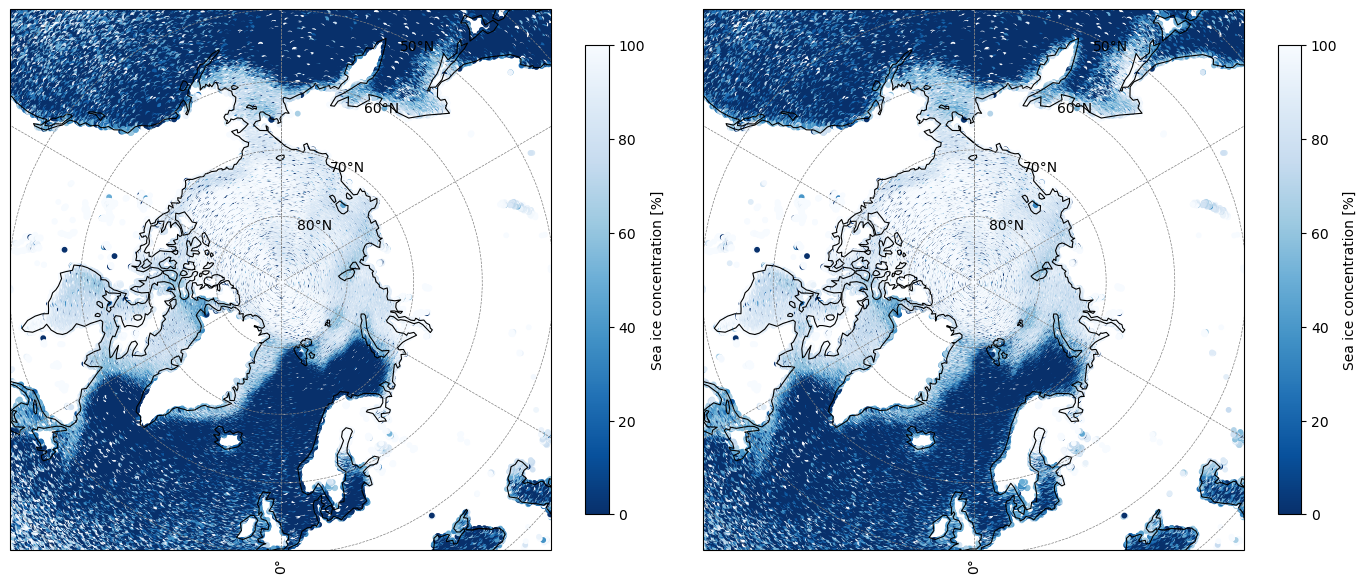

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
import pyresample as pr
from pyresample import kd_tree, parse_area_file
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from pyresample.geometry import SwathDefinition
import sys, string, math, cmath
from numba import jit 
from tqdm import tqdm 
import time 
from pyresample.geometry import SwathDefinition
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import FixedLocator 
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import maximum_filter, minimum_filter

# Load data
file_path = "data_swath_final.txt" 
df = pd.read_csv(file_path, delim_whitespace=True)

# Variable selection
var1_name = "siconc_unc_2_channels"
var2_name = "siconc_corr_2_channels"
lat_name = "LAT"  
lon_name = "LON"  

# Convert in numpy array
lats = df[lat_name].values
lons = df[lon_name].values
var1 = df[var1_name].values*100
var2 = df[var2_name].values*100

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 7), subplot_kw={'projection': ccrs.NorthPolarStereo()})

for ax, var, title in zip(axs, [var1, var2], [var1_name, var2_name]):
    ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    
    # Variable selection
    sc = ax.scatter(lons, lats, c=var, cmap="Blues_r", s=10, transform=ccrs.PlateCarree())

    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.05)
    cbar.set_label("Sea ice concentration [%]")

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
    gl.top_labels = False  
    gl.right_labels = False  
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}


plt.tight_layout()
plt.show()

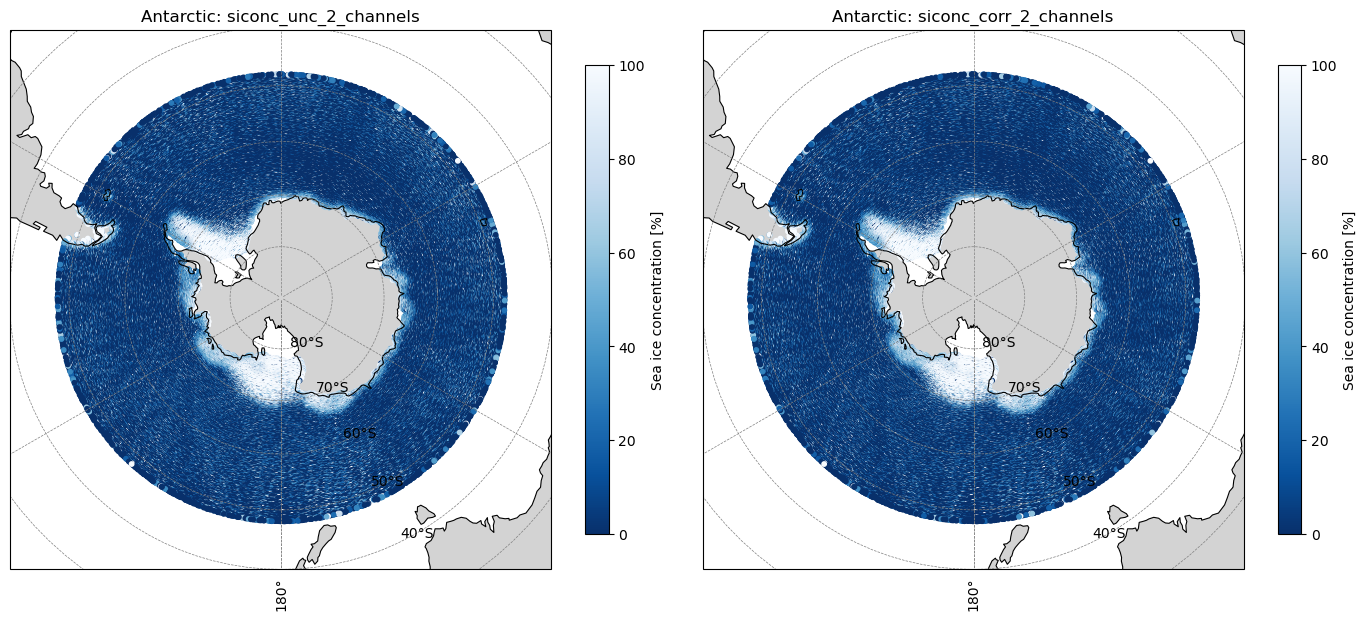

In [143]:
# Load data
file_path = "data_swath_final.txt" 
df = pd.read_csv(file_path, delim_whitespace=True)

# Variable selection
var1_name = "siconc_unc_2_channels"
var2_name = "siconc_corr_2_channels"
lat_name = "LAT"  
lon_name = "LON"  

# Convert in numpy array
lats = df[lat_name].values
lons = df[lon_name].values
var1 = df[var1_name].values*100
var2 = df[var2_name].values*100

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 7), subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax, var, title in zip(axs, [var1, var2], [var1_name, var2_name]):
    ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    
    # Variable selection
    sc = ax.scatter(lons, lats, c=var, cmap="Blues_r", s=10, transform=ccrs.PlateCarree())

    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.05)
    cbar.set_label("Sea ice concentration [%]")

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
    gl.top_labels = False  
    gl.right_labels = False  
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}


plt.tight_layout()
plt.show()

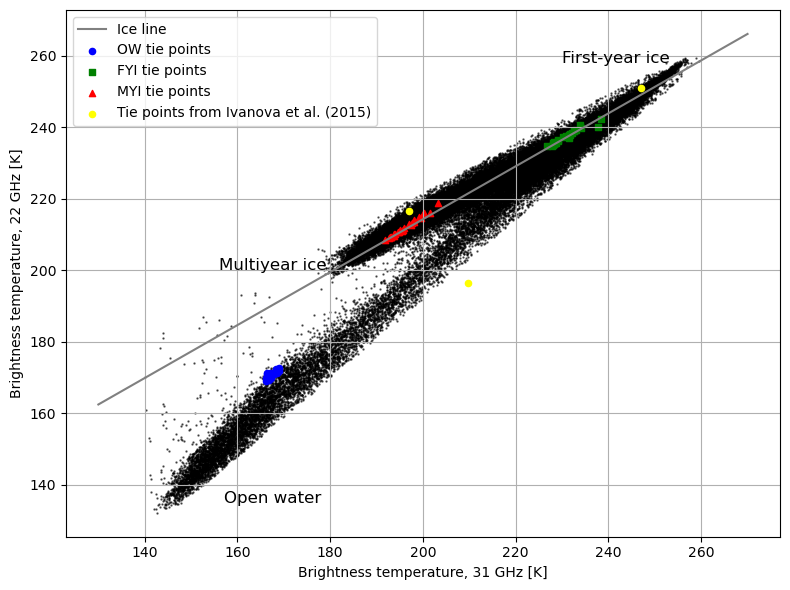

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caricamento e filtro iniziale
file_path = "data_swath_final.txt" 
tp_file = "daily_tie_points_nh_corr.txt"
tp_df = pd.read_csv(tp_file)
df = pd.read_csv(file_path, delim_whitespace=True)
df = df[(df['LAT'] >= 70) & (df['LAT'] <= 90)]

points = [
    (209.81, 196.41),  # Open Water
    (247.13, 250.87),  # First-Year Ice
    (196.91, 216.67)   # Multi-Year Ice
]

# Unzip into x and y lists
x_valss, y_valss = zip(*points)

# Bounding box iniziale
df_filtered = df[
    (df['TBCH2'] >= 140) & (df['TBCH2'] <= 260) &
    (df['TBCH1'] >= 130) & (df['TBCH1'] <= 260)
]

# Filtraggio tra due rette oblique
m1 = (260 - 180) / (255 - 140)
q1 = 180 - m1 * 140
m2 = (253 - 148) / (255 - 160)
q2 = 148 - m2 * 160
TBCH2 = df_filtered['TBCH2']
TBCH1 = df_filtered['TBCH1']
mask = (TBCH1 <= m1 * TBCH2 + q1) & (TBCH1 >= m2 * TBCH2 + q2)
df_filtered = df_filtered[mask]
tp_df = tp_df[
    (tp_df['tp_open_water_22ghz_nh'] <= m1 * tp_df['tp_open_water_32ghz_nh'] + q1) &
    (tp_df['tp_open_water_22ghz_nh'] >= m2 * tp_df['tp_open_water_32ghz_nh'] + q2) &
    (tp_df['tp_fyi_ice_22ghz_nh']      <= m1 * tp_df['tp_fyi_ice_32ghz_nh']      + q1) &
    (tp_df['tp_fyi_ice_22ghz_nh']      >= m2 * tp_df['tp_fyi_ice_32ghz_nh']      + q2) &
    (tp_df['tp_myi_ice_22ghz_nh']      <= m1 * tp_df['tp_myi_ice_32ghz_nh']      + q1) &
    (tp_df['tp_myi_ice_22ghz_nh']      >= m2 * tp_df['tp_myi_ice_32ghz_nh']      + q2)
]

# Definisci due punti qualsiasi per calcolare la retta
x1, y1 = 180, 199.5
x2, y2 = 255, 255

# Calcola coefficiente angolare e intercetta
m = (y2 - y1) / (x2 - x1)
q = y1 - m * x1

# Crea valori x su tutta l'estensione del grafico
x_vals = np.linspace(130, 270, 500)  # esteso oltre i punti
y_vals = m * x_vals + q
angle = np.degrees(np.arctan(m))

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['TBCH2'], df_filtered['TBCH1'], color='black', s=0.5, alpha=0.6)

plt.plot(x_vals, y_vals, color='grey', linestyle='-', linewidth=1.5, label='Ice line')

plt.scatter(tp_df['tp_open_water_32ghz_nh'], tp_df['tp_open_water_22ghz_nh'],
            color='blue', marker='o', s=20, label='OW tie points')

plt.scatter(tp_df['tp_fyi_ice_32ghz_nh'], tp_df['tp_fyi_ice_22ghz_nh'],
            color='green', marker='s', s=20, label='FYI tie points')

plt.scatter(tp_df['tp_myi_ice_32ghz_nh'], tp_df['tp_myi_ice_22ghz_nh'],
            color='red', marker='^', s=20, label='MYI tie points')

plt.scatter(x_valss, y_valss, color='yellow', s=20, label='Tie points from Ivanova et al. (2015)')

# Disegna la retta completa

plt.text(230, 258, 'First-year ice', fontsize=12, color='black')
plt.text(156, 200, 'Multiyear ice', fontsize=12, color='black')
plt.text(157, 135, 'Open water', fontsize=12, color='black')

# Dettagli grafico

plt.xlabel('Brightness temperature, 31 GHz [K]')
plt.ylabel('Brightness temperature, 22 GHz [K]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Tb_space', dpi=300, bbox_inches='tight')
plt.show()


In [28]:
import pandas as pd
df = pd.read_csv('daily_tie_points_nh.txt')  # Sostituisci con il nome esatto del file
colonna = 'tp_open_water_22ghz_nh'  # Cambia il nome della colonna se vuoi analizzare un'altra
mean_val = df[colonna].mean()
std_val = df[colonna].std()
std_percent = (std_val / mean_val) * 100
print(f"devst {colonna}: {std_percent:.2f}%")
print(std_val)

devst tp_open_water_22ghz_nh: 0.92%
1.5727459595654767


In [34]:
import pandas as pd
df = pd.read_csv('daily_tie_points_nh2.txt')  # Sostituisci con il nome esatto del file
colonna = 'tp_open_water_22ghz'  # Cambia il nome della colonna se vuoi analizzare un'altra
mean_val = df[colonna].mean()
std_val = df[colonna].std()
std_percent = (std_val / mean_val) * 100
print(f"devst {colonna}: {std_percent:.2f}%")
print(std_val)

devst tp_open_water_22ghz: 0.73%
1.2461801714670488
